PCA (Principal Component Analysis): We do dimensionality Reduction with PCA which allows us to reduce the number of factors thats allow predictions to be more valuable with less columns


In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Iris.csv')
print(f"Data Set Loaded with {df.shape[0]} Rows and {df.shape[1]} Columns")

Data Set Loaded with 150 Rows and 6 Columns


In [3]:
print(f"{df.isnull().sum()}")

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
df= df.drop(columns = ["Id"])

In [5]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
40,5.0,3.5,1.3,0.3,Iris-setosa
121,5.6,2.8,4.9,2.0,Iris-virginica
1,4.9,3.0,1.4,0.2,Iris-setosa
124,6.7,3.3,5.7,2.1,Iris-virginica
105,7.6,3.0,6.6,2.1,Iris-virginica


In [6]:
features = df.iloc[:,:-1]
target = df.iloc[:,-1]
pca = PCA(n_components= 2)
X_pca = pca.fit_transform(features)


In [7]:
X_pca

array([[-2.68420713,  0.32660731],
       [-2.71539062, -0.16955685],
       [-2.88981954, -0.13734561],
       [-2.7464372 , -0.31112432],
       [-2.72859298,  0.33392456],
       [-2.27989736,  0.74778271],
       [-2.82089068, -0.08210451],
       [-2.62648199,  0.17040535],
       [-2.88795857, -0.57079803],
       [-2.67384469, -0.1066917 ],
       [-2.50652679,  0.65193501],
       [-2.61314272,  0.02152063],
       [-2.78743398, -0.22774019],
       [-3.22520045, -0.50327991],
       [-2.64354322,  1.1861949 ],
       [-2.38386932,  1.34475434],
       [-2.6225262 ,  0.81808967],
       [-2.64832273,  0.31913667],
       [-2.19907796,  0.87924409],
       [-2.58734619,  0.52047364],
       [-2.3105317 ,  0.39786782],
       [-2.54323491,  0.44003175],
       [-3.21585769,  0.14161557],
       [-2.30312854,  0.10552268],
       [-2.35617109, -0.03120959],
       [-2.50791723, -0.13905634],
       [-2.469056  ,  0.13788731],
       [-2.56239095,  0.37468456],
       [-2.63982127,

In [8]:
pca_df = pd.DataFrame(data = X_pca, columns= ["Principal Component 1", "Principal Component 2"])
pca_df["target"] = target.values

print("\nExplained variance ratio per principal component:")
print(pca.explained_variance_ratio_)
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.2f}")

print("\nDataFrame with Principal Components:")
print(pca_df.head())



Explained variance ratio per principal component:
[0.92461621 0.05301557]
Total explained variance: 0.98

DataFrame with Principal Components:
   Principal Component 1  Principal Component 2       target
0              -2.684207               0.326607  Iris-setosa
1              -2.715391              -0.169557  Iris-setosa
2              -2.889820              -0.137346  Iris-setosa
3              -2.746437              -0.311124  Iris-setosa
4              -2.728593               0.333925  Iris-setosa


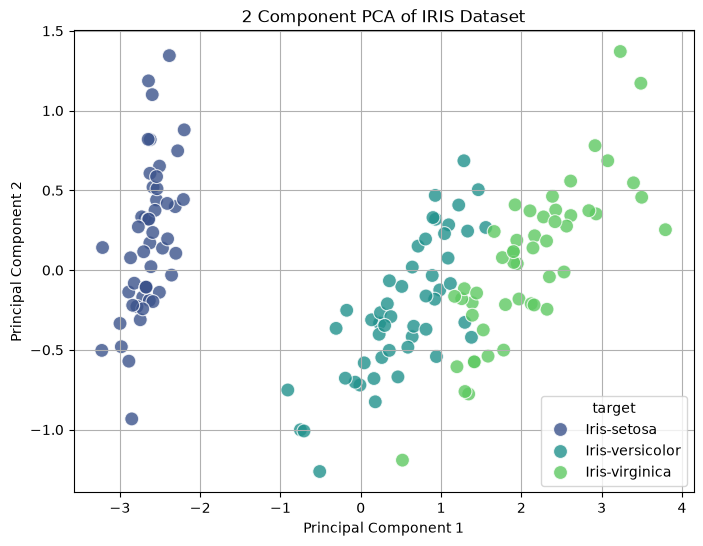

In [9]:
# Visualize the PCA results (for 2 components)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='target', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('2 Component PCA of IRIS Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [10]:
weather_df = pd.read_csv("weather_forecast_data.csv")

In [12]:
weather_df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [23]:
features = weather_df.iloc[:,:-1]
target = weather_df.iloc[:,-1]
Wpca = PCA(n_components= 3)
X_Wpca = Wpca.fit_transform(features)


In [24]:
# Wpca_df = pd.DataFrame(data = X_Wpca, columns= ["Principal Component 1", "Principal Component 2","PC3","PC4"])
Wpca_df = pd.DataFrame(data = X_Wpca, columns= ["Principal Component 1", "Principal Component 2","PC3"])
# Wpca_df = pd.DataFrame(data = X_Wpca, columns= ["Principal Component 1", "Principal Component 2"])
# Wpca_df = pd.DataFrame(data = X_Wpca, columns= ["Principal Component 1"])
Wpca_df["target"] = target.values

print("\nExplained variance ratio per principal component:")
print(Wpca.explained_variance_ratio_)
print(f"Total explained variance: {sum(Wpca.explained_variance_ratio_):.2f}")

print("\nDataFrame with Principal Components:")
print(Wpca_df.head())





Explained variance ratio per principal component:
[0.48733094 0.23929057 0.22338008]
Total explained variance: 0.95

DataFrame with Principal Components:
   Principal Component 1  Principal Component 2        PC3   target
0               1.610731               0.196399  30.992297     rain
1             -45.450590              -6.559805 -26.044722  no rain
2             -34.838587             -15.904536  12.027527  no rain
3              16.706588             -32.025729 -10.492675     rain
4              -2.732621             -46.074736   7.341540  no rain


In [33]:
c_df = pd.read_csv("cardio_train.csv",sep=";")
print(c_df.head(5))
print(c_df.shape)

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)


In [34]:
features = c_df.iloc[:,:-1]
target = c_df.iloc[:,-1]
Cpca = PCA(n_components= 3)
X_Cpca = Cpca.fit_transform(features)

In [ ]:
# Cpca_df = pd.DataFrame(data = X_Cpca, columns= ["Principal Component 1", "Principal Component 2","Principal Component 3","Principal Component 4"])
Cpca_df = pd.DataFrame(data = X_Cpca, columns= ["Principal Component 1", "Principal Component 2","Principal Component 3"])
# Cpca_df = pd.DataFrame(data = X_Cpca, columns= ["Principal Component 1", "Principal Component 2"])
# Cpca_df = pd.DataFrame(data = X_Cpca, columns= ["Principal Component 1"])
Cpca_df["target"] = target.values

print("\nExplained variance ratio per principal component:")
print(Wpca.explained_variance_ratio_)
print(f"Total explained variance: {sum(Wpca.explained_variance_ratio_):.2f}")

print("\nDataFrame with Principal Components:")
print(Wpca_df.head())





Explained variance ratio per principal component:
[0.48733094 0.23929057 0.22338008]
Total explained variance: 0.95

DataFrame with Principal Components:
   Principal Component 1  Principal Component 2        PC3   target
0               1.610731               0.196399  30.992297     rain
1             -45.450590              -6.559805 -26.044722  no rain
2             -34.838587             -15.904536  12.027527  no rain
3              16.706588             -32.025729 -10.492675     rain
4              -2.732621             -46.074736   7.341540  no rain
